In [15]:
import os
import numpy as np
import pandas as pd


# Load train / validation

data_dir = os.path.join(os.getcwd(), "Data/processed")
train_path = os.path.join(data_dir, "train_data.csv")
val_path   = os.path.join(data_dir, "validation_data.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Columns:", train_df.columns.tolist())

# Select count-like features for Poisson

count_features = [
    "games",            # total games played
    "minutes_played",   # total minutes played
    "points",           # total points
    "total_rebounds",   # total rebounds
    "assists"           # total assists
]

# Sanity check: make sure all columns exist
for col in count_features:
    if col not in train_df.columns:
        raise ValueError(f"Column {col} not found in train_data.csv")
    if col not in val_df.columns:
        raise ValueError(f"Column {col} not found in validation_data.csv")

# Fill missing values with 0, cast to integer counts
X_train = train_df[count_features].fillna(0).astype(int).values  # (N_train, P)
X_val   = val_df[count_features].fillna(0).astype(int).values    # (N_val, P)

N_train, P = X_train.shape
N_val, _   = X_val.shape
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Concatenate train + val for one model
#    (so the NumPyro plates have fixed size)
X_all = np.concatenate([X_train, X_val], axis=0)  # (N_total, P)
N_total = X_all.shape[0]
split_idx = N_train  # first N_train rows are training players
print("X_all shape:", X_all.shape)

# standardize features for better optimization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_train_scaled = X_all_scaled[:N_train]
X_val_scaled = X_all_scaled[N_train:]


Train shape: (1616, 24)
Val shape: (53, 24)
Columns: ['id', 'year', 'rank', 'overall_pick', 'team', 'player', 'college', 'years_active', 'games', 'minutes_played', 'points', 'total_rebounds', 'assists', 'field_goal_percentage', '3_point_percentage', 'free_throw_percentage', 'average_minutes_played', 'points_per_game', 'average_total_rebounds', 'average_assists', 'win_shares', 'win_shares_per_48_minutes', 'box_plus_minus', 'value_over_replacement']
X_train shape: (1616, 5)
X_val shape: (53, 5)
X_all shape: (1669, 5)


**CV_Tuning_MSE**

In [2]:
from Train import cross_validate_on_train
from Model import StyleModelConfig


candidate_configs = [
    StyleModelConfig(K=3, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
    StyleModelConfig(K=5, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
    StyleModelConfig(K=7, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
]

# -----------------------------------------------------------------
# Cross-validation on train_data (validation_data is untouched here)
# -----------------------------------------------------------------
cv_results = cross_validate_on_train(
    train_df,
    candidate_configs=candidate_configs,
    n_splits=3,      # small N in this dataset; you can change to 5 if larger
    num_steps=1500,  # fewer steps for CV runs
    base_seed=42,
)

# Pick best config by lowest mean MSE
best = min(cv_results, key=lambda r: r.mean_mse)
print("\n[CV] Summary of configs:")
for r in cv_results:
    print(
        f"  Config K={r.config.K}, alpha={r.config.alpha}: "
        f"mean MSE={r.mean_mse:.4f} ± {r.std_mse:.4f}"
    )

print(
    f"\n[CV] Best config: K={best.config.K}, "
    f"alpha={best.config.alpha}, MSE={best.mean_mse:.4f}"
)

# -----------------------------------------------------------------
# Train final model on full train_data, evaluate on validation_data
# -----------------------------------------------------------------

from Train import train_style_topic_model
best_config = best.config
posterior_all = train_style_topic_model(
    X_all_scaled,
    config=best_config,
    num_steps=4000,
    lr=1e-2,
    seed=123,
)
loss_trace = posterior_all["loss_trace"]



[CV] Evaluating config 1/3: StyleModelConfig(K=3, alpha=0.5, tau_beta=1.0, tau_sigma=1.0)
[CV]  Fold 1/3
[TRAIN] step=375, loss=46561.707
[TRAIN] step=750, loss=32271.447
[TRAIN] step=1125, loss=26804.816
[TRAIN] step=1500, loss=24330.375
[TRAIN] step=375, loss=24582.195
[TRAIN] step=750, loss=17885.502
[CV]    Fold 1 MSE = 0.9647
[CV]  Fold 2/3
[TRAIN] step=375, loss=27870.871
[TRAIN] step=750, loss=25518.012
[TRAIN] step=1125, loss=22800.805
[TRAIN] step=1500, loss=21212.484
[TRAIN] step=375, loss=13848.664
[TRAIN] step=750, loss=12259.208
[CV]    Fold 2 MSE = 1.0882
[CV]  Fold 3/3
[TRAIN] step=375, loss=29795.795
[TRAIN] step=750, loss=24512.043
[TRAIN] step=1125, loss=22083.215
[TRAIN] step=1500, loss=20014.672
[TRAIN] step=375, loss=23388.176
[TRAIN] step=750, loss=16888.402
[CV]    Fold 3 MSE = 1.1805
[CV] Config StyleModelConfig(K=3, alpha=0.5, tau_beta=1.0, tau_sigma=1.0) -> mean MSE = 1.0778 ± 0.0884

[CV] Evaluating config 2/3: StyleModelConfig(K=5, alpha=0.5, tau_beta=1.0, 

ImportError: cannot import name 'train_style_topic_model' from 'Train' (d:\Files\documents\GitHub\Unsupervised-Machine-Learning-Final-Project\Code\Train.py)

**training**

In [75]:
import jax
import jax.numpy as jnp
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal  # or AutoMultivariateNormal
import pickle
import os

from Train import build_design_matrix
from Model import style_topic_model, StyleModelConfig

# ===========================================
# Global SVI training on X_train_std (Gaussian model)
# ===========================================

# Assume you already determined the best hyperparameters (e.g. from CV):
# Example:
# best_config = StyleModelConfig(K=5, alpha=0.5, tau_beta=1.0, tau_sigma=1.0)
# If you don't have this yet, define best_config accordingly.
best_config = StyleModelConfig(K=7, alpha=0.5, tau_beta=1.0, tau_sigma=1.0)

# Learning rate and number of SVI steps
lr = 1e-2
num_steps = 4000

X_train_std, stats_train = build_design_matrix(train_df, stats=None)

# Convert training data (already standardized) to JAX array
X_train_jax = jnp.asarray(X_train_std, dtype=jnp.float32)

# Guide: mean-field Gaussian over all latent variables (theta, beta, sigma)
# You can also try AutoMultivariateNormal for a richer posterior.
guide = AutoNormal(style_topic_model)

# Optimizer + SVI object
optimizer = Adam(lr)
svi = SVI(
    style_topic_model,
    guide,
    optimizer,
    loss=Trace_ELBO(),
)

# Initialize SVI state
rng_key = jax.random.PRNGKey(0)
svi_state = svi.init(rng_key, X_train_jax, config=best_config)

# Run optimization
losses = []  # training loss history
for step in range(num_steps):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss_val = svi.update(svi_state, X_train_jax, config=best_config)
    loss_val = float(loss_val)
    losses.append(loss_val)
    if step % 500 == 0:
        print(f"[TRAIN] step={step}, loss={loss_val:.3f}")

print("[TRAIN] SVI finished.")

# Get trained variational parameters
params = svi.get_params(svi_state)

# Posterior sampling to obtain posterior means of theta, beta, sigma
predictive = Predictive(
    model=style_topic_model,
    guide=guide,
    params=params,
    num_samples=500,
    return_sites=["theta", "beta", "sigma"],
)
rng_key, subkey = jax.random.split(rng_key)
posterior_samples = predictive(subkey, X_train_jax, config=best_config)

theta_train = jnp.array(posterior_samples["theta"]).mean(axis=0)   # (N_train, K)
beta        = jnp.array(posterior_samples["beta"]).mean(axis=0)    # (K, P)
sigma       = jnp.array(posterior_samples["sigma"]).mean(axis=0)   # (P,)

print(f"[POST] theta_train shape: {theta_train.shape}")
print(f"[POST] beta shape:        {beta.shape}")
print(f"[POST] sigma shape:       {sigma.shape}")

# Save params + posterior means to disk
# Include K/config in the filename to avoid confusion.
model_params_path = os.path.join(data_dir, f"gaussian_style_model_K{best_config.K}.pkl")
with open(model_params_path, "wb") as f:
    pickle.dump(
        {
            "config": best_config,
            "params": params,          # variational parameters
            "theta_train": theta_train,  # posterior means
            "beta": beta,
            "sigma": sigma,
            "losses": losses,          # optional: training loss history
        },
        f,
    )

print(f"[TRAIN] Saved model + posterior means to: {model_params_path}")


[TRAIN] step=0, loss=106031.734
[TRAIN] step=500, loss=23675.930
[TRAIN] step=1000, loss=22152.295
[TRAIN] step=1500, loss=21771.025
[TRAIN] step=2000, loss=21421.354
[TRAIN] step=2500, loss=21337.322
[TRAIN] step=3000, loss=21211.289
[TRAIN] step=3500, loss=21243.434
[TRAIN] SVI finished.
[POST] theta_train shape: (1616, 7)
[POST] beta shape:        (7, 10)
[POST] sigma shape:       (10,)
[TRAIN] Saved model + posterior means to: d:\Files\documents\GitHub\Unsupervised-Machine-Learning-Final-Project\Code\Data/processed\gaussian_style_model_K7.pkl


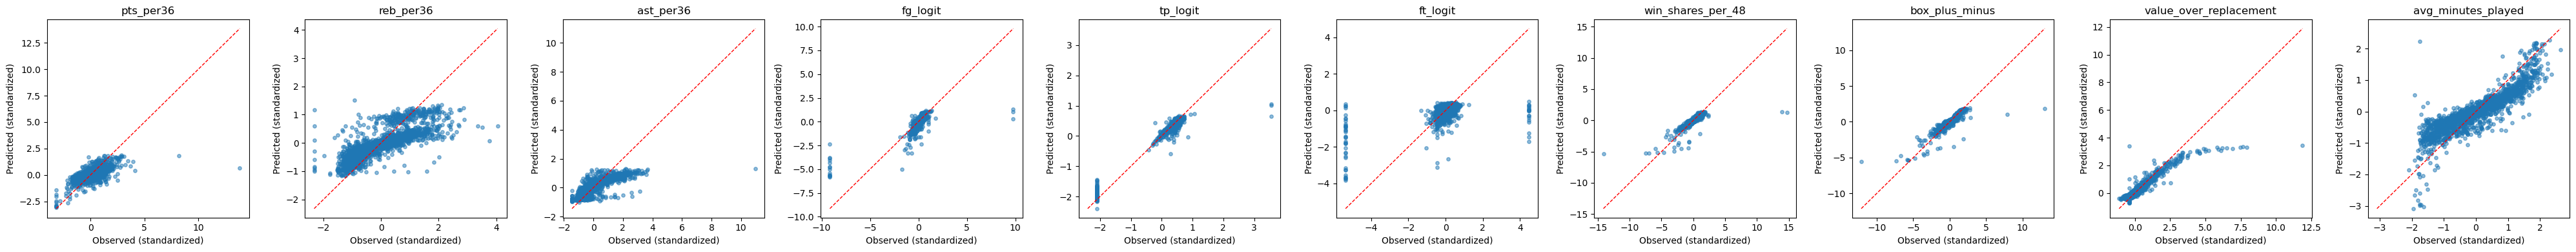

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Observed standardized features on training set
X_train_obs = X_train_std                      # (N_train, P)

# Predicted features using the style model
X_train_pred = np.array(theta_train @ beta)    # (N_train, P)

P = X_train_obs.shape[1]

fig, axes = plt.subplots(1, P, figsize=(4 * P, 4))

for i in range(P):
    ax = axes[i]

    ax.scatter(
        X_train_obs[:, i],
        X_train_pred[:, i],
        alpha=0.5,
        s=15,
    )

    # y = x reference line
    min_val = min(X_train_obs[:, i].min(), X_train_pred[:, i].min())
    max_val = max(X_train_obs[:, i].max(), X_train_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1)

    ax.set_title(stats_train.feature_names[i])
    ax.set_xlabel("Observed (standardized)")
    ax.set_ylabel("Predicted (standardized)")

plt.tight_layout()
plt.show()


[TRAIN] step=500, loss=2546.610
[TRAIN] step=1000, loss=1738.110
[TRAIN] step=1500, loss=1350.625
X_val_obs shape: (53, 10)
X_val_pred shape: (53, 10)


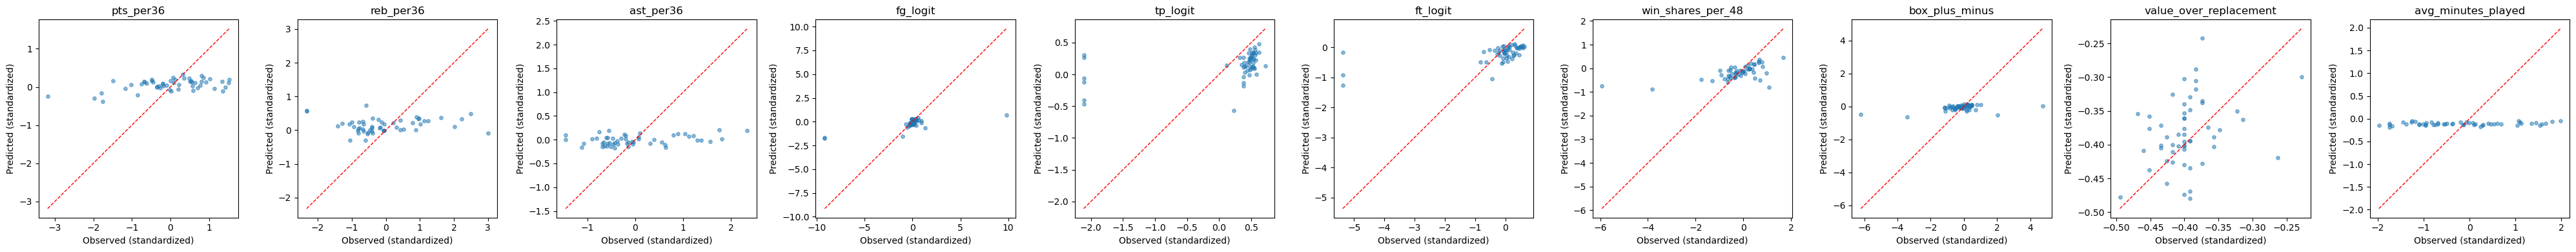

In [80]:
# 1) 标准化 validation 特征（用训练集的 mean/std）
X_val_std, _ = build_design_matrix(val_df, stats=stats_train)

# 2) 在 validation 上重新 fit 一个模型（和 train 用同一个 config）
from Train import fit_style_model
_, _, theta_val, beta_val, _ = fit_style_model(
    X_val_std,
    config=best_config,
    num_steps=1500,
    rng_seed=123,
    log_every=500,
)

# 3) 观测值 & 预测值
X_val_obs = X_val_std                       # (N_val, P)
X_val_pred = np.array(theta_val @ beta_val) # (N_val, P)

print("X_val_obs shape:", X_val_obs.shape)
print("X_val_pred shape:", X_val_pred.shape)  # 这里应该都是 (N_val, P)

# 4) 画图
P = X_val_obs.shape[1]

fig, axes = plt.subplots(1, P, figsize=(4 * P, 4))

for i in range(P):
    ax = axes[i]

    ax.scatter(
        X_val_obs[:, i],
        X_val_pred[:, i],
        alpha=0.5,
        s=15,
    )

    min_val = min(X_val_obs[:, i].min(), X_val_pred[:, i].min())
    max_val = max(X_val_obs[:, i].max(), X_val_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1)

    ax.set_title(stats_train.feature_names[i])
    ax.set_xlabel("Observed (standardized)")
    ax.set_ylabel("Predicted (standardized)")

plt.tight_layout()
plt.show()


**Style Interpretation**

In [82]:
import numpy as np

# Example: feature names must match the columns of X_std / beta_mean
# If you used Train.py's build_design_matrix, they are:
feature_names = [
    "pts_per36",
    "reb_per36",
    "ast_per36",
    "fg_logit",
    "tp_logit",
    "ft_logit",
    "win_shares_per_48",
    "box_plus_minus",
    "value_over_replacement",
    "avg_minutes_played",
]

# Optional: map internal feature keys to more readable labels for printing
FEATURE_NAME_MAP = {
    "pts_per36": "PTS per 36",
    "reb_per36": "REB per 36",
    "ast_per36": "AST per 36",
    "fg_logit": "FG% (logit)",
    "tp_logit": "3P% (logit)",
    "ft_logit": "FT% (logit)",
    "win_shares_per_48": "WS/48",
    "box_plus_minus": "BPM",
    "value_over_replacement": "VORP",
    "avg_minutes_played": "Avg minutes",
}


def pretty_name(name: str) -> str:
    """Map internal feature name to a human-readable label."""
    return FEATURE_NAME_MAP.get(name, name)


def print_style_interpretation(
    beta_mean: np.ndarray,
    feature_names: list,
    top_n: int = 5,
) -> None:
    """
    Print a human-readable interpretation of each style based on beta loadings.

    For each style k:
      - Show top `top_n` positive loadings (features that are high in this style).
      - Show top `top_n` negative loadings (features that are low in this style).

    Parameters
    ----------
    beta_mean : np.ndarray, shape (K, P)
        Mean style loadings from the Gaussian style model.
    feature_names : list of str, length P
        Names of features corresponding to columns of beta_mean.
    top_n : int
        Number of top positive and negative features to display per style.
    """
    K, P = beta_mean.shape

    for k in range(K):
        print(f"\n=== Style {k} ===")
        beta_k = beta[k]
        std_k = np.std(beta_k)

        # Positive = significantly above mean
        pos_idx = np.where(beta_k > 0.5 * std_k)[0]
        neg_idx = np.where(beta_k < -0.5 * std_k)[0]

        print("  Strong positive features:")
        for idx in pos_idx:
            print(f"    {feature_names[idx]:20s}  {beta_k[idx]:.3f}")

        print("  Strong negative features:")
        for idx in neg_idx:
            print(f"    {feature_names[idx]:20s}  {beta_k[idx]:.3f}")


# Usage example (after you have beta_mean from SVI / Predictive):
beta_mean = np.array(posterior_samples["beta"]).mean(axis=0)  # (K, P)
print_style_interpretation(beta_mean, feature_names, top_n=5)



=== Style 0 ===
  Strong positive features:
  Strong negative features:
    pts_per36             -3.116
    reb_per36             -1.053
    ast_per36             -0.979
    fg_logit              -5.933
    tp_logit              -2.071
    ft_logit              -3.875
    win_shares_per_48     -5.422
    box_plus_minus        -5.604
    avg_minutes_played    -3.125

=== Style 1 ===
  Strong positive features:
    fg_logit              0.375
    tp_logit              0.594
    ft_logit              0.311
    win_shares_per_48     0.380
    box_plus_minus        0.435
    avg_minutes_played    0.495
  Strong negative features:
    ast_per36             -0.507
    value_over_replacement  -0.260

=== Style 2 ===
  Strong positive features:
    reb_per36             1.953
    fg_logit              1.620
    win_shares_per_48     1.187
  Strong negative features:
    ast_per36             -1.239
    tp_logit              -3.172

=== Style 3 ===
  Strong positive features:
    pts_per36    

NameError: name 'K' is not defined

### Style 0 – 低效率边缘轮换（Low-impact Role Player）
- 命中率与产出全面偏低，进攻威胁有限。
- 特点：低 FG/FT/3P，低 PTS/AST/REB，分钟数少。

### Style 1 – 外线射手（Catch-and-Shoot Spacer）
- 主要贡献来自外线投篮，但整体价值（BPM/VORP）不高。
- 特点：高 FG/3P/FT，低组织、低防守影响。

### Style 2 – 传统内线（Traditional Center / Interior Finisher）
- 强项在篮板与禁区终结，无外线能力。
- 特点：高 REB、高 FG%，几乎不投 3 分，组织与持球较弱。

### Style 3 – 组织后卫（Primary Ball Handler / Facilitator）
- 持球与组织为核心技能，投篮次之。
- 特点：AST per 36 非常高，使用率稳定。

### Style 4 – 得分侧翼（On-ball Scoring Wing）
- 高出手量、高得分能力，效率不错。
- 特点：PTS per 36、三项命中率较好，承担稳定得分角色。

### Style 5 – 全能明星（All-around Superstar）
- 全局贡献极高（BPM, VORP, WS/48 全领先）。
- 特点：强得分、高组织、高效率、高稳定性。

### Style 6 – 现代 3&D 前锋 / 现代中锋（Modern 3-and-D Forward / Stretch Big）
- 高效率外线（含大个投篮）+ 优质防守与篮板。
- 特点：好 3P、好 REB、效率高，角色功能多样（可对应“现代中锋”）。


In [67]:
style_names = {
    0: "Low-impact rotation player",
    1: "Catch-and-shoot spacer",
    2: "Traditional interior big",
    3: "Primary ball-handler / facilitator",
    4: "On-ball scoring wing",
    5: "All-around superstar",
    6: "Modern 3-and-D forward / stretch big",
}

star_indices = {
    "LeBron James": 673,
    "Kobe Bryant": 342,
    "Stephen Curry": 979,
    "Kyrie Irving": 1074,
    "Tim Duncan": 377,
    "Yao Ming": 625,
}


model_features = [
    "PTS per 36",
    "REB per 36",
    "AST per 36",
    "Avg minutes",
    "FG% (logit)",
    "3P% (logit)",
    "FT% (logit)",
    "WS/48",
    "BPM",
    "VORP",
]



In [68]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_player_by_index(
    idx,
    df,
    theta,
    rate,
    K,
    style_names=None,
    build_design_matrix=None,
    design_matrix_kwargs=None,
):
    """
    Visualize one player under the NEW continuous-feature style model:
      (1) style mixture theta[idx]
      (2) observed vs predicted standardized features (same scale as model)

    This version:
      - does NOT take X or scaler from outside;
      - rebuilds X via `build_design_matrix(df, **kwargs)`;
      - assumes X and `rate = theta @ beta` are on the same standardized scale.

    Parameters
    ----------
    idx : int
        Row index of the player in df.
    df : pd.DataFrame
        DataFrame containing player info, must include at least 'player', 'year'.
    theta : array-like, shape (N, K)
        Style mixture for each player.
    rate : array-like, shape (N, P)
        Predicted features for each player on the SAME SCALE as X
        (typically `rate = theta @ beta_mean`).
    K : int
        Number of style topics.
    style_names : dict or None
        Optional mapping k -> style name for nicer x-axis labels.
    build_design_matrix : callable
        Function used in training to build the design matrix, e.g.
            X, feature_info = build_design_matrix(df, **design_matrix_kwargs)
        where feature_info can be either:
            - a list of feature names, or
            - an object with attribute `.feature_names`.
    design_matrix_kwargs : dict or None
        Extra keyword arguments passed to `build_design_matrix`.
    """
    if build_design_matrix is None:
        raise ValueError("You must provide `build_design_matrix` for the new model.")

    if design_matrix_kwargs is None:
        design_matrix_kwargs = {}

    # -----------------------------------------
    # Rebuild design matrix to match the model
    # -----------------------------------------
    X, feature_info = build_design_matrix(df, **design_matrix_kwargs)
    X = np.asarray(X)
    theta = np.asarray(theta)
    rate = np.asarray(rate)

    # 兼容 FeatureStats / list 两种情况
    if hasattr(feature_info, "feature_names"):
        feature_names = list(feature_info.feature_names)
    else:
        feature_names = list(feature_info)

    # Sanity checks on shapes
    if not (X.shape[0] == theta.shape[0] == rate.shape[0]):
        raise ValueError(
            f"Row mismatch: X={X.shape[0]}, theta={theta.shape[0]}, rate={rate.shape[0]}."
        )

    P_X = X.shape[1]
    P_rate = rate.shape[1]
    P_names = len(feature_names)
    if not (P_X == P_rate == P_names):
        raise ValueError(
            f"Feature dimension mismatch: X dim={P_X}, rate dim={P_rate}, "
            f"len(feature_names)={P_names}. Make sure build_design_matrix "
            f"and beta / rate use the SAME P features in the SAME order."
        )

    # ------------- pick this player -------------
    row = df.iloc[idx]
    player_name = row["player"]
    year = row["year"]

    theta_vec = theta[idx]             # (K,)
    obs_vec   = X[idx].astype(float)   # (P,)
    rate_vec  = rate[idx].astype(float)  # (P,)

    # ------------------------
    # 1) Style mixture subplot
    # ------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax0 = axes[0]
    x_styles = np.arange(K)
    ax0.bar(x_styles, theta_vec)
    if style_names is not None:
        x_labels = [style_names.get(k, str(k)) for k in range(K)]
    else:
        x_labels = [str(k) for k in range(K)]
    ax0.set_xticks(x_styles)
    ax0.set_xticklabels(x_labels, rotation=45, ha="right")
    ax0.set_ylim(0.0, 1.0)
    ax0.set_ylabel("Proportion")
    ax0.set_title(f"Style mixture for {player_name} ({int(year)})")

    # -------------------------------
    # 2) Observed vs predicted (model scale)
    # -------------------------------
    x_pos = np.arange(P_names)
    width = 0.35
    ax1 = axes[1]
    ax1.bar(x_pos - width / 2, obs_vec,  width=width, label="Observed (model scale)")
    ax1.bar(x_pos + width / 2, rate_vec, width=width, label="Predicted (theta @ beta)")
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(feature_names, rotation=45, ha="right")
    ax1.set_title("Observed vs predicted features (standardized)")
    ax1.legend()

    plt.tight_layout()
    plt.show()


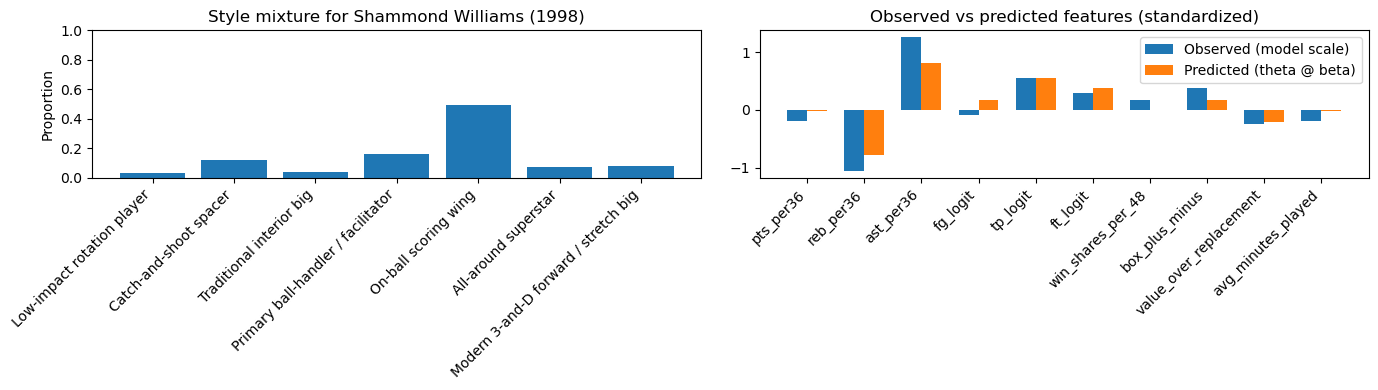

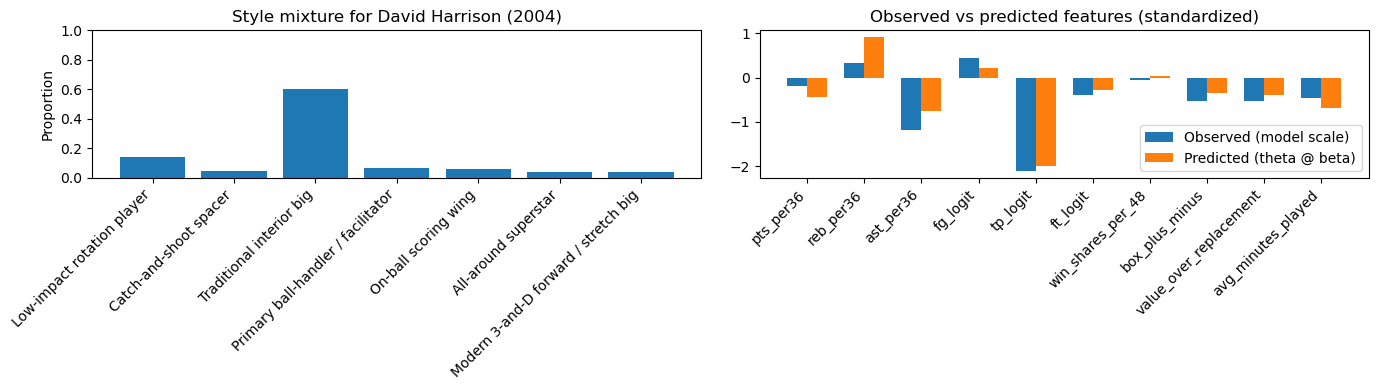

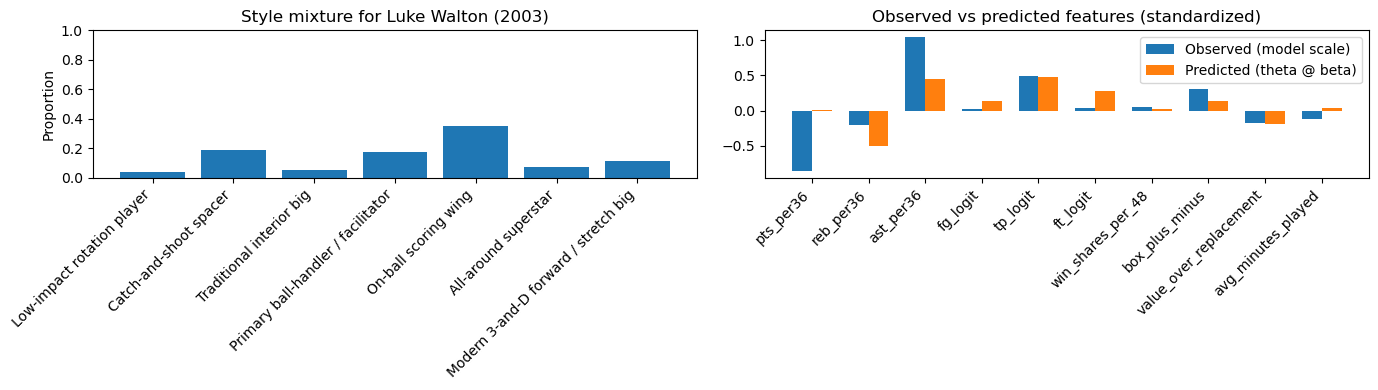

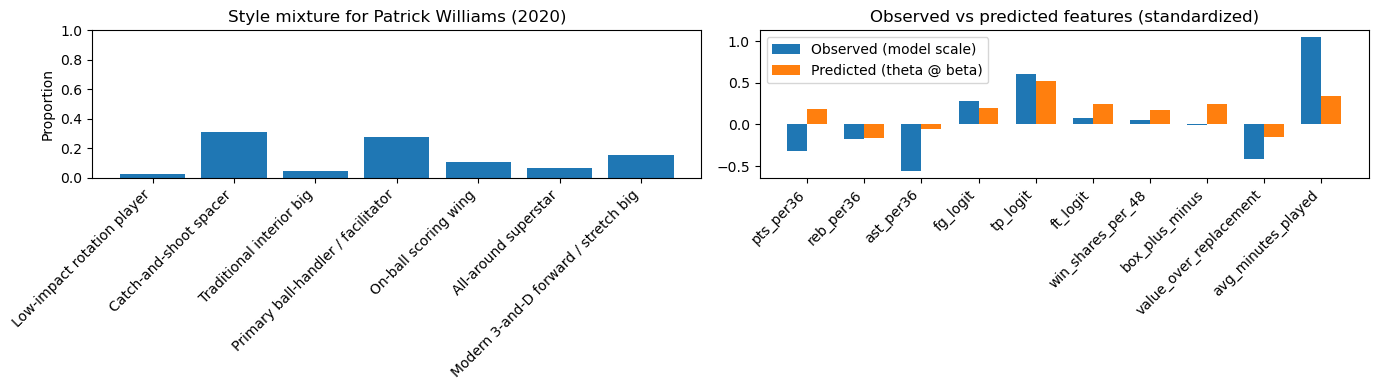

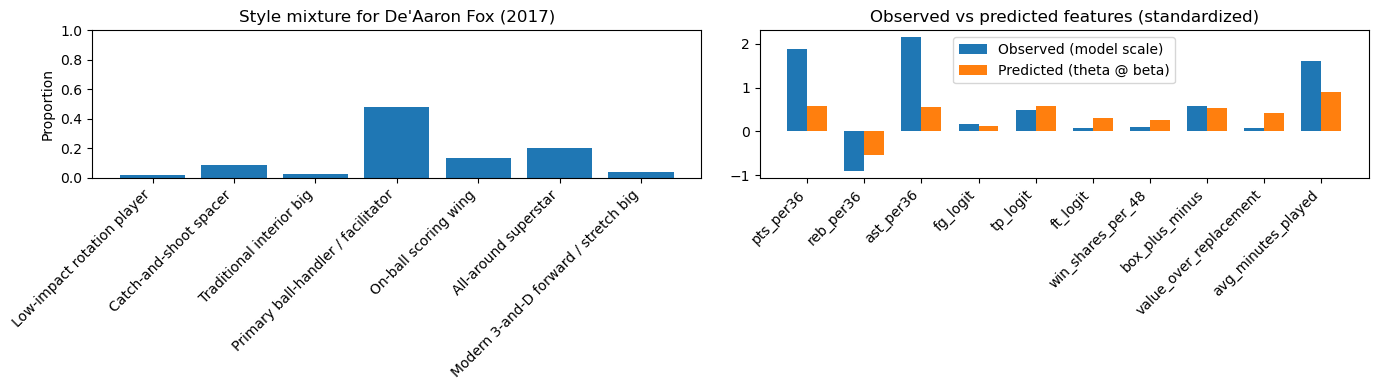

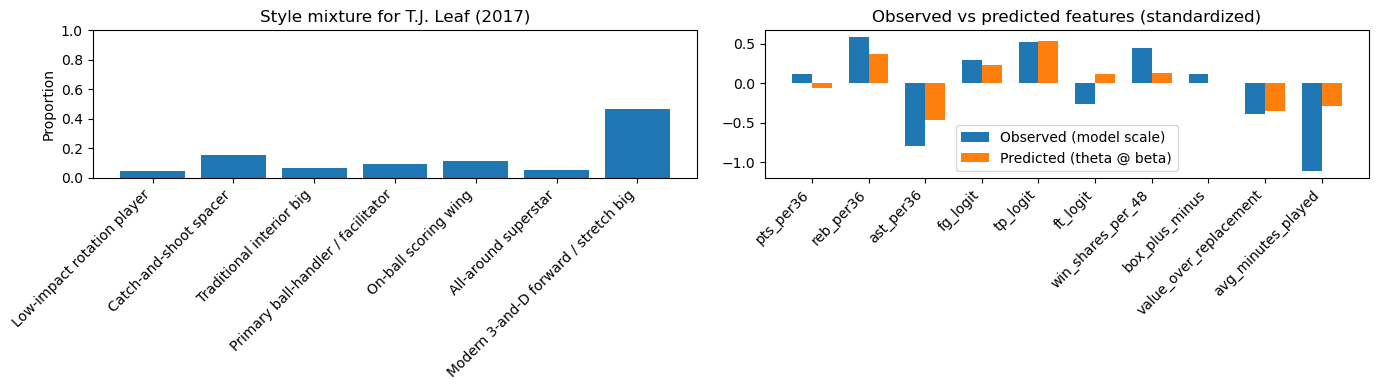

In [69]:
# randomly pick 6 players to visualize
np.random.seed(123)
random_indices = np.random.choice(train_df.shape[0], size=6, replace=False)
for idx in random_indices:
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_train,      
        rate=theta_train @ beta,            
        K=theta_train.shape[1],
        style_names=style_names,
        build_design_matrix=build_design_matrix,
        design_matrix_kwargs={"stats": stats_train},
    )

**for superstars**

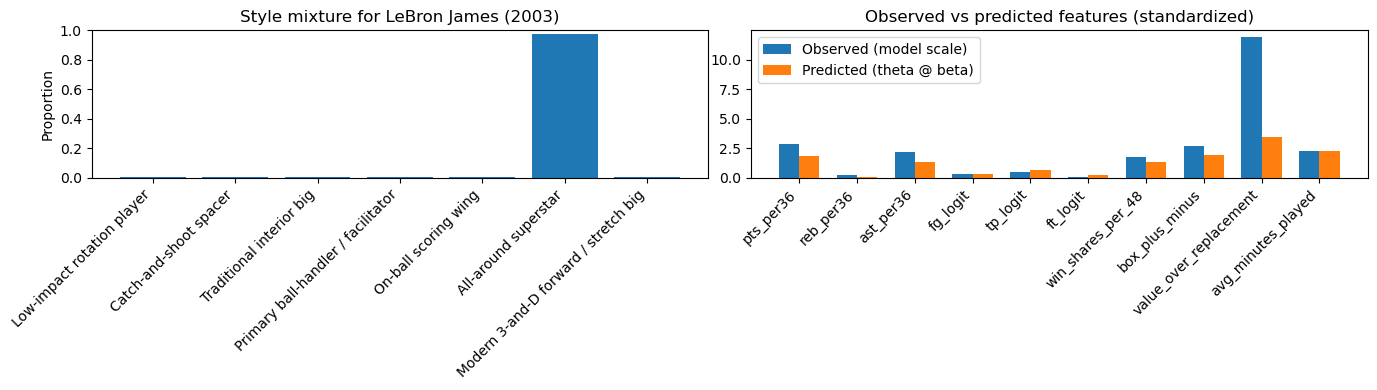

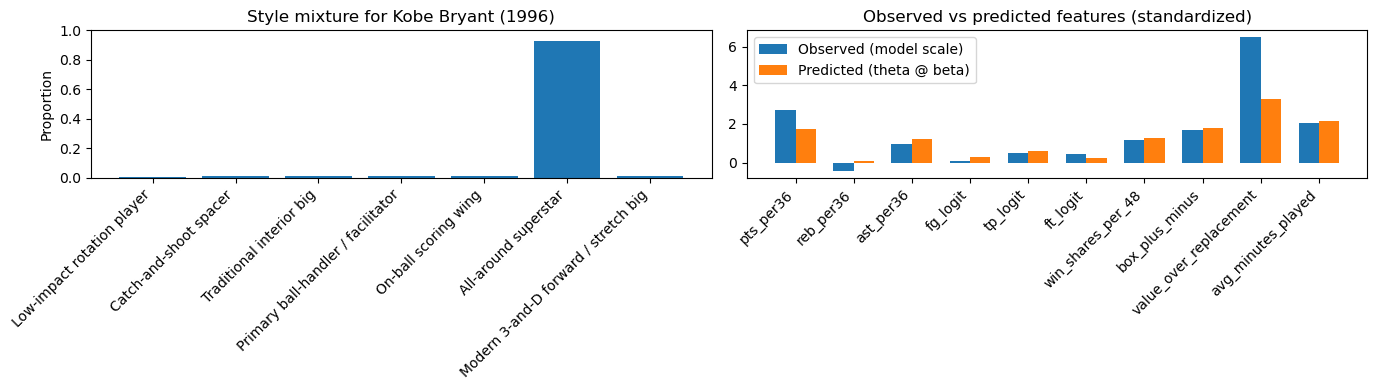

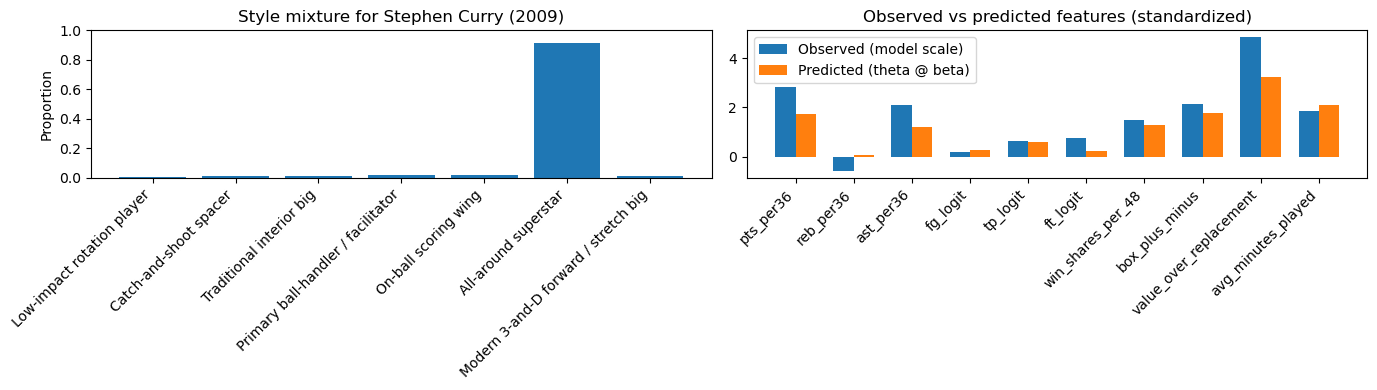

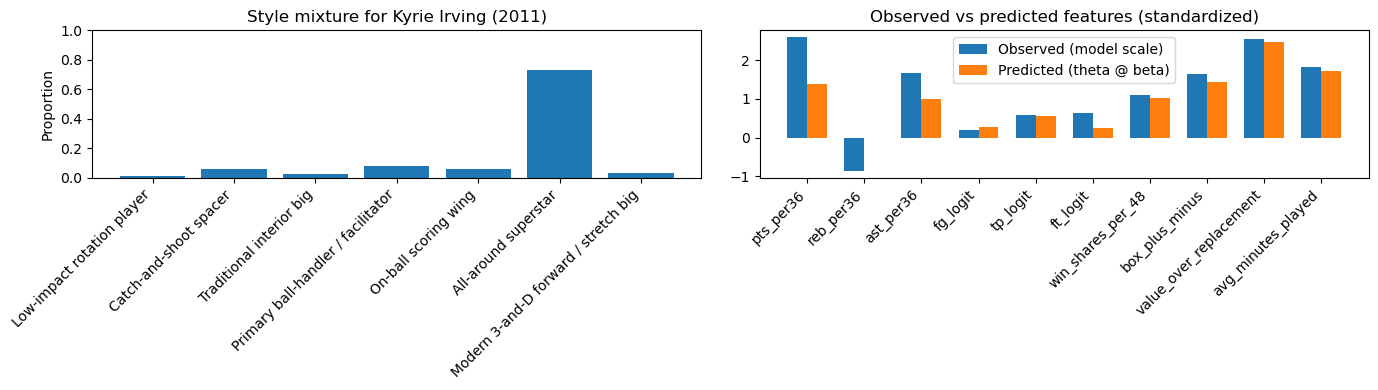

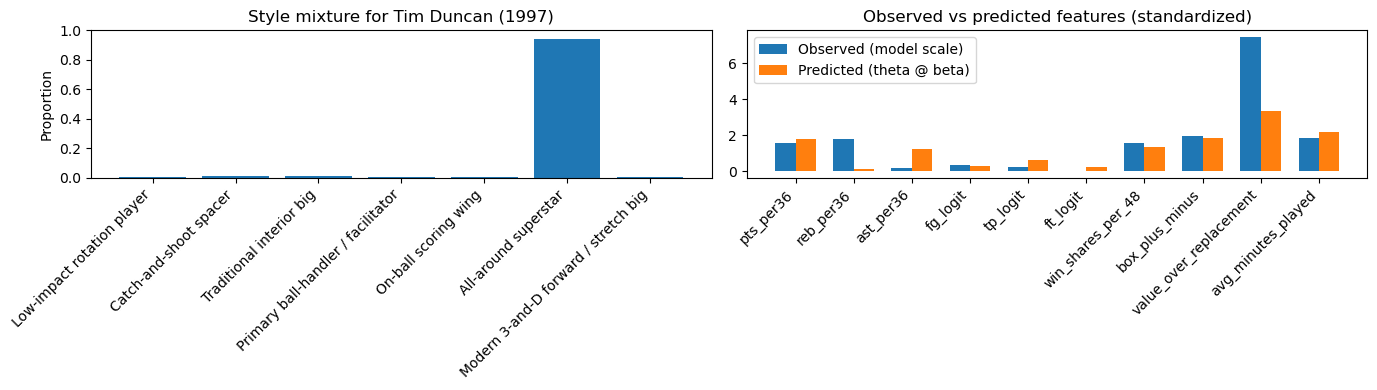

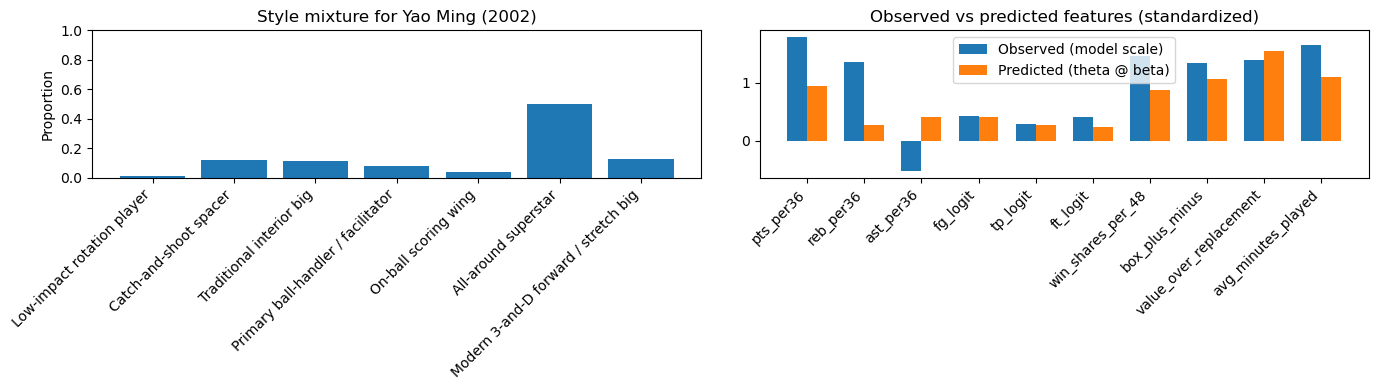

In [72]:
for player, idx in star_indices.items():
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_train,      
        rate=theta_train @ beta,            
        K=theta_train.shape[1],
        style_names=style_names,
        build_design_matrix=build_design_matrix,
        design_matrix_kwargs={"stats": stats_train},
    )

In [70]:
def remove_style_and_renormalize(theta, remove_k):
    """
    Remove one style (remove_k) from theta and renormalize the rest.

    theta: (N, K)
    remove_k: int, index to remove

    return: new_theta (N, K-1)
    """
    theta = np.asarray(theta)
    N, K = theta.shape

    # 1. Remove the column
    mask = np.array([k for k in range(K) if k != remove_k])
    theta_reduced = theta[:, mask]  # (N, K-1)

    # 2. Renormalize
    s = theta_reduced.sum(axis=1, keepdims=True)
    new_theta = theta_reduced / s

    return new_theta, mask

theta_no_super, keep_mask = remove_style_and_renormalize(
    theta_train,
    remove_k=5,  # assuming style 5 is "All-around superstar"
)
beta_reduced = beta[keep_mask, :]     # (K-1, P)
rate_no_super = theta_no_super @ beta_reduced  # (N, P)


--- Visualizing LeBron James (index 673) without superstar style ---


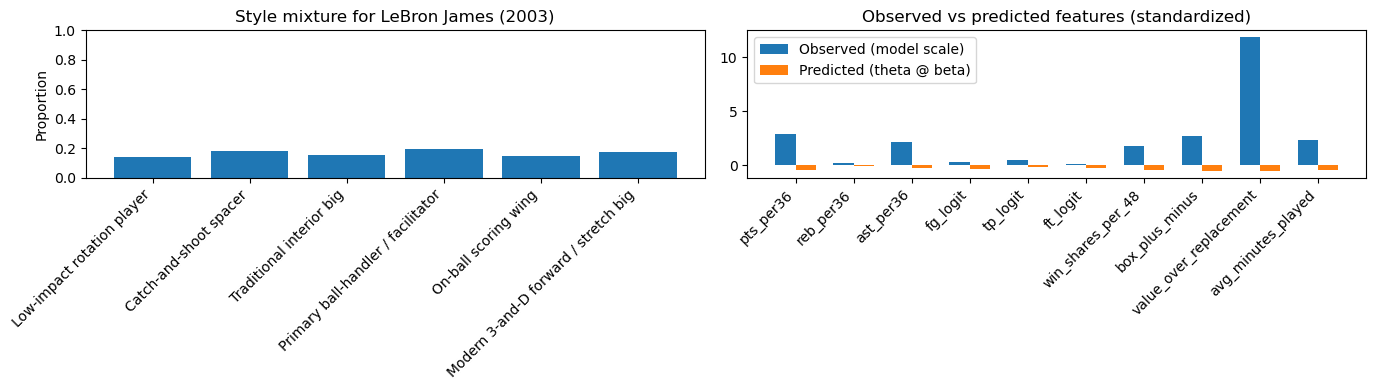


--- Visualizing Kobe Bryant (index 342) without superstar style ---


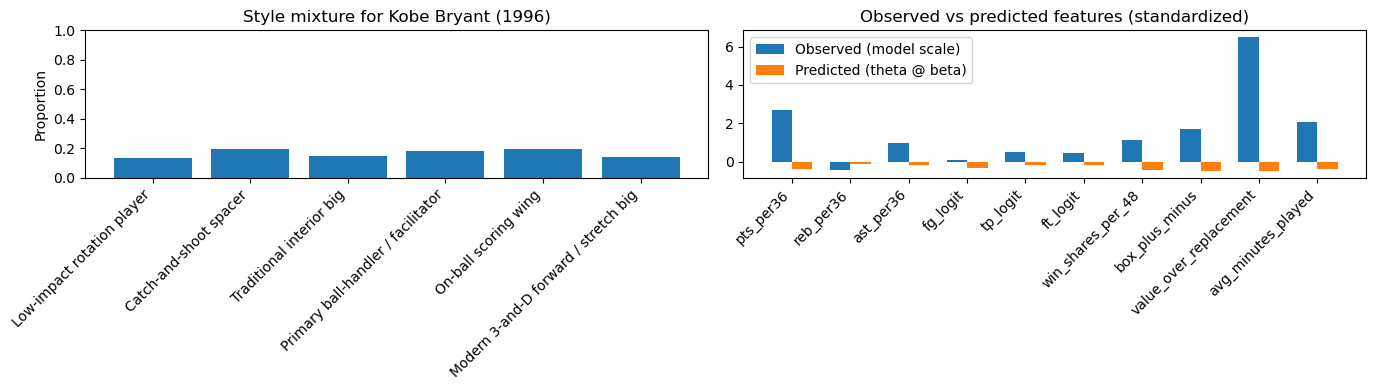


--- Visualizing Stephen Curry (index 979) without superstar style ---


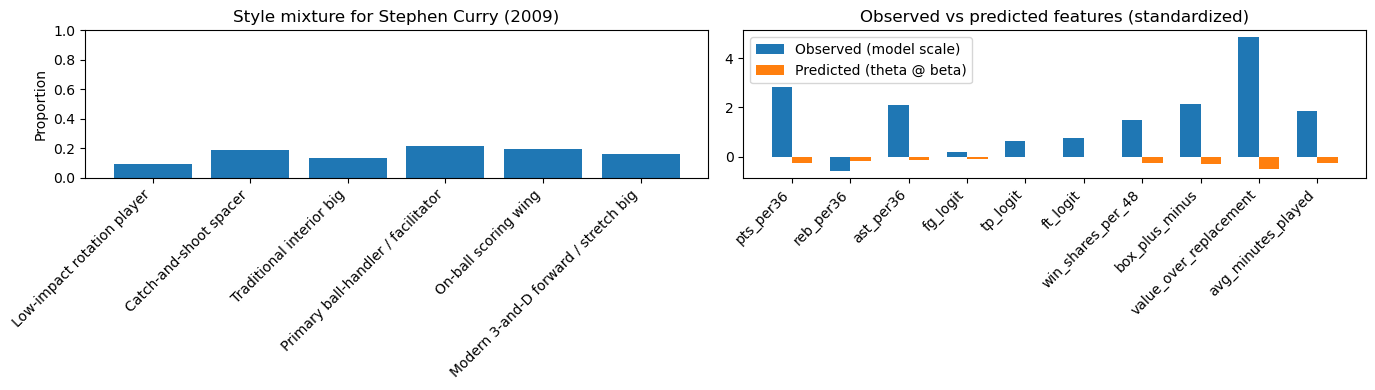


--- Visualizing Kyrie Irving (index 1074) without superstar style ---


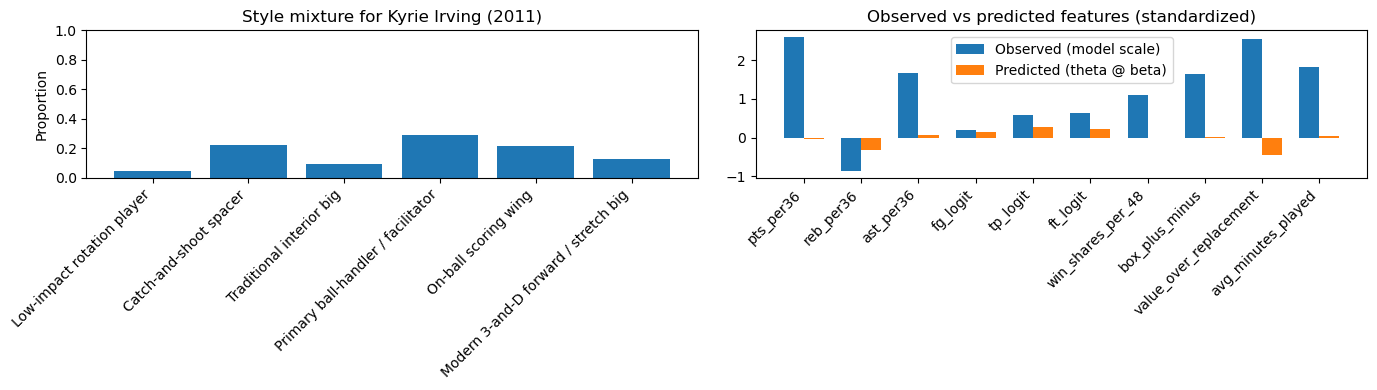


--- Visualizing Tim Duncan (index 377) without superstar style ---


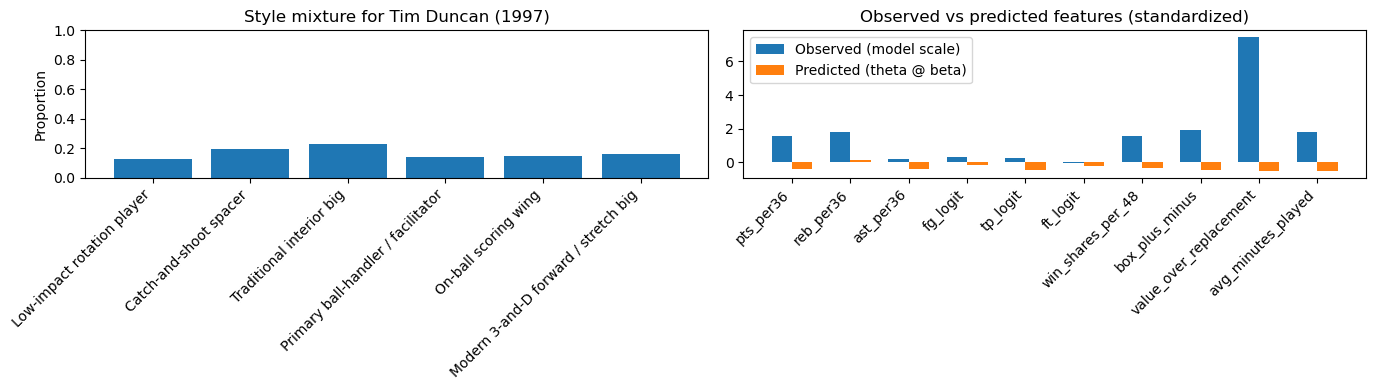


--- Visualizing Yao Ming (index 625) without superstar style ---


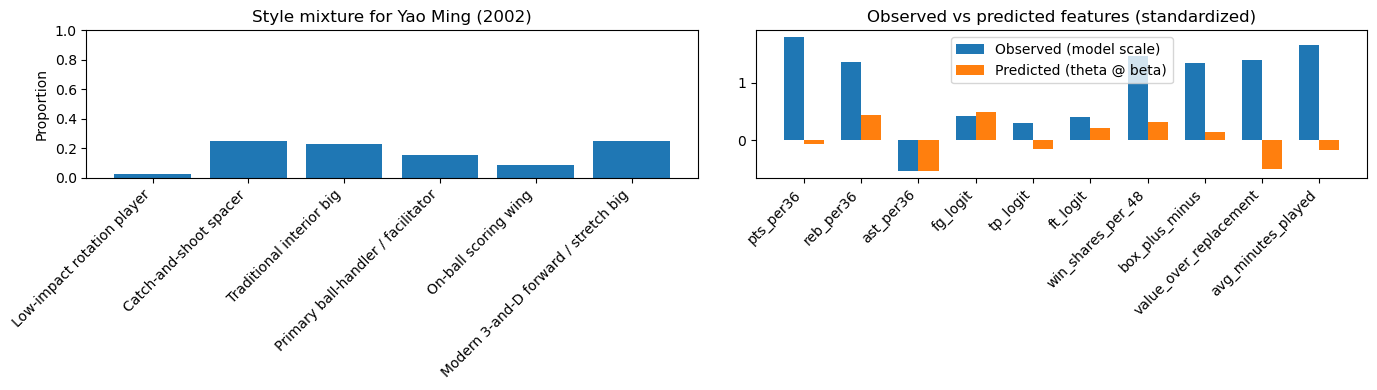

In [71]:
# drop all around superstar from style names
style_names_reduced = {
    0: "Low-impact rotation player",
    1: "Catch-and-shoot spacer",
    2: "Traditional interior big",
    3: "Primary ball-handler / facilitator",
    4: "On-ball scoring wing",
    5: "Modern 3-and-D forward / stretch big",
}

for player, idx in star_indices.items():
    print(f"\n--- Visualizing {player} (index {idx}) without superstar style ---")
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_no_super,      
        rate=theta_no_super @ beta[keep_mask, :],           
        K=theta_no_super.shape[1],
        style_names=style_names_reduced,
        build_design_matrix=build_design_matrix,
        design_matrix_kwargs={"stats": stats_train},
    )